# Flood Detection Cascade — SIH26177

**SIH26177 — Autonomous SAR Drone, on-device hazard detection**

This notebook trains the two-stage flood detection cascade:

1. **Stage 1** — binary classifier (flooded / not flooded), trained on **AIDERv2**'s Flood class.
2. **Stage 2** — binary water segmentation (U-Net), trained on **FloodNet**'s masks, only
   run at inference time on frames Stage 1 flags as flooded.

**Why the cascade?** A flat "flooded: yes/no" label doesn't tell rescue teams where the
dry ground (and therefore potential survivor locations near the water's edge) actually
is. Stage 2 only runs when Stage 1 triggers, so the heavier segmentation model isn't
wasted on non-flooded frames — this matters for eventual on-device inference where
compute is scarce.

This is a standalone notebook — self-contained, no dependency on any other notebook.
Collapsed-building classification is trained separately (`collapsed_building_detection.ipynb`).
Fire detection (D-Fire, existing cascade) and human detection (HERIDAL/SARD) are also
handled in their own notebooks.


In [1]:
import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)}")
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("Could not set memory growth:", e)

print("TensorFlow:", tf.__version__)


GPUs available: 0
TensorFlow: 2.20.0


2026-09-18 10:59:15.095503: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
# ----------------------------- Global config -----------------------------
CLF_IMG_SIZE   = (224, 224)     # classifier input size
SEG_IMG_SIZE   = (256, 256)     # segmentation input size (power-of-2 friendly for U-Net)
BATCH_SIZE     = 32
AUTOTUNE       = tf.data.AUTOTUNE

CLF_HEAD_EPOCHS   = 10   # phase 1: frozen backbone
CLF_FINETUNE_EPOCHS = 15 # phase 2: fine-tune last N layers
CLF_FINETUNE_UNFREEZE_FROM_END = 100   # unfreeze last 100 layers of MobileNetV2

SEG_HEAD_EPOCHS   = 10
SEG_FINETUNE_EPOCHS = 20
SEG_FINETUNE_UNFREEZE_LAST = 30


## Environment — Local vs Kaggle\n\nFlip `RUNNING_ON_KAGGLE` to `True` once this notebook is uploaded to Kaggle with the datasets attached. Until then, it runs locally against the paths you set below.

In [3]:
# ----------------------------- Environment toggle -----------------------------
RUNNING_ON_KAGGLE = True   # flip to True once this notebook is on Kaggle with datasets attached

if RUNNING_ON_KAGGLE:
    OUT_DIR = "/kaggle/working"
else:
    # ---- EDIT THESE for your local machine ----
    AIDER_ROOT_LOCAL = r"C:\datasets"                 # folder that directly contains Train/ Test/ Val/
    FLOODNET_ROOT_LOCAL = r"C:\path\to\FloodNet"     # edit once you have FloodNet locally
    OUT_DIR = "./outputs"

os.makedirs(OUT_DIR, exist_ok=True)
print("RUNNING_ON_KAGGLE:", RUNNING_ON_KAGGLE)
print("OUT_DIR:", OUT_DIR)

RUNNING_ON_KAGGLE: True
OUT_DIR: /kaggle/working


## Section A — Dataset Discovery\n\nLocate AIDERv2 and FloodNet (on Kaggle: auto-detected under `/kaggle/input/`; locally: the paths set above), print their structure, and auto-detect FloodNet's mask convention before writing any loader code.

In [4]:
def walk_tree(root_dir, max_depth=4, max_print_per_dir=1):
    root_dir = os.path.abspath(root_dir)
    for dirpath, dirnames, filenames in os.walk(root_dir):
        depth = dirpath[len(root_dir):].count(os.sep)
        if depth > max_depth:
            dirnames[:] = []
            continue
        indent = "  " * depth
        print(f"{indent}{os.path.basename(dirpath) or dirpath}/")
        if filenames:
            exts = {}
            for f in filenames:
                ext = os.path.splitext(f)[1].lower()
                exts[ext] = exts.get(ext, 0) + 1
            summary = ", ".join(f"{c}x {e or '(no ext)'}" for e, c in exts.items())
            print(f"{indent}  -> {len(filenames)} files ({summary})")
            for f in filenames[:max_print_per_dir]:
                print(f"{indent}  -> sample: {f}")


def find_dataset_folder(keyword):
    """Return the first folder under /kaggle/input whose name contains `keyword` (top level only)."""
    for d in os.listdir(INPUT_ROOT):
        if keyword.lower() in d.lower():
            return os.path.join(INPUT_ROOT, d)
    return None


def find_dir_by_name(root, keyword, max_depth=4):
    """Recursively search under `root` for a directory whose name contains `keyword` (case-insensitive)."""
    root = os.path.abspath(root)
    for dirpath, dirnames, _ in os.walk(root):
        depth = dirpath[len(root):].count(os.sep)
        if depth > max_depth:
            dirnames[:] = []
            continue
        if keyword.lower() in os.path.basename(dirpath).lower():
            return dirpath
    return None


if RUNNING_ON_KAGGLE:
    INPUT_ROOT = "/kaggle/input"
    print("Datasets attached under /kaggle/input:")
    for d in sorted(os.listdir(INPUT_ROOT)):
        print(" -", d)

    AIDER_ROOT = "/kaggle/input/datasets/aaliyah06/aiderv2"
    FLOODNET_ROOT = find_dir_by_name(INPUT_ROOT, "track 1")
    print()
    print("AIDERv2 root (hardcoded)          :", AIDER_ROOT)
    print("FloodNet root (Track 1, auto-found):", FLOODNET_ROOT)
    print("If either is None or wrong, set AIDER_ROOT / FLOODNET_ROOT manually here.")
else:
    AIDER_ROOT = "/kaggle/input/datasets/aaliyah06/aiderv2"
    FLOODNET_ROOT = FLOODNET_ROOT_LOCAL
    print("Using local paths:")
    print("AIDER_ROOT   :", AIDER_ROOT)
    print("FLOODNET_ROOT:", FLOODNET_ROOT)

# Manual override (uncomment + edit if the above picked the wrong folder):
# AIDER_ROOT = "<exact-path>"
# FLOODNET_ROOT = "<exact-path>"

Datasets attached under /kaggle/input:
 - datasets

AIDERv2 root (hardcoded)          : /kaggle/input/datasets/aaliyah06/aiderv2
FloodNet root (Track 1, auto-found): /kaggle/input/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge/FloodNet Challenge - Track 1
If either is None or wrong, set AIDER_ROOT / FLOODNET_ROOT manually here.


In [5]:
assert AIDER_ROOT is not None, "Could not auto-locate AIDERv2 — set AIDER_ROOT manually."

print("=== AIDERv2 structure ===")
walk_tree(AIDER_ROOT, max_depth=4)


=== AIDERv2 structure ===
aiderv2/
  Val/
    Val/
      Flood/
        -> 505 files (505x .png)
        -> sample: image_281.png
      Normal/
        -> 487 files (487x .png)
        -> sample: image_1171.png
      Fire/
        -> 439 files (439x .png)
        -> sample: image_1659.png
      Earthquake/
        -> 239 files (239x .png)
        -> sample: image_1.png
  Test/
    Test/
      Flood/
        -> 502 files (502x .png)
        -> sample: image_281.png
      Normal/
        -> 477 files (477x .png)
        -> sample: image_1171.png
      Fire/
        -> 436 files (436x .png)
        -> sample: image_1330.png
      Earthquake/
        -> 239 files (239x .png)
        -> sample: image_1.png
  Train/
    Train/
      Flood/
        -> 4063 files (4063x .png)
        -> sample: image_4213.png
      Normal/
        -> 3900 files (3900x .png)
        -> sample: image_8559.png
      Fire/
        -> 3509 files (3509x .png)
        -> sample: image_10572.png
      Earthquake/
    

In [6]:
def find_aider_split_dirs(aider_root):
    """
    AIDERv2's expected layout: {Train,Val,Test}/{Earthquake,Flood,Normal,Fire}/
    (folder may be doubly-nested, e.g. Train/Train/Earthquake/ — this function
    searches at any depth, so that's handled automatically)
    Some repackaged copies drop the 'Dataset_Images' wrapper or rename Val->Validation.
    Search for the folder that directly contains the 4 class subfolders.
    """
    class_names = {"earthquake", "flood", "normal", "fire"}
    split_aliases = {
        "train": ["train"],
        "val":   ["val", "validation"],
        "test":  ["test"],
    }
    found = {}
    for dirpath, dirnames, filenames in os.walk(aider_root):
        lower_subdirs = {d.lower() for d in dirnames}
        if class_names.issubset(lower_subdirs):
            base = os.path.basename(dirpath).lower()
            for split_key, aliases in split_aliases.items():
                if base in aliases:
                    found[split_key] = dirpath
    return found


def resolve_class_dir(split_dir, class_name):
    for d in os.listdir(split_dir):
        if d.lower() == class_name.lower():
            return os.path.join(split_dir, d)
    raise FileNotFoundError(f"Class '{class_name}' not found under {split_dir}")


AIDER_CLASSES = ["Earthquake", "Flood", "Normal", "Fire"]

aider_splits = find_aider_split_dirs(AIDER_ROOT)
print("Resolved AIDERv2 split directories:")
for k, v in aider_splits.items():
    print(f"  {k:5s} -> {v}")

assert set(aider_splits.keys()) == {"train", "val", "test"}, (
    f"Could not resolve all 3 splits, found: {aider_splits}. "
    "Inspect the tree above and set paths manually."
)

count_rows = []
for split_key, split_dir in aider_splits.items():
    for cls in AIDER_CLASSES:
        cls_dir = resolve_class_dir(split_dir, cls)
        n = len([f for f in os.listdir(cls_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
        count_rows.append({"split": split_key, "class": cls, "count": n})

aider_counts_df = pd.DataFrame(count_rows).pivot(index="class", columns="split", values="count")
aider_counts_df["total"] = aider_counts_df.sum(axis=1)
print()
print(aider_counts_df)


Resolved AIDERv2 split directories:
  val   -> /kaggle/input/datasets/aaliyah06/aiderv2/Val/Val
  test  -> /kaggle/input/datasets/aaliyah06/aiderv2/Test/Test
  train -> /kaggle/input/datasets/aaliyah06/aiderv2/Train/Train

split       test  train  val  total
class                              
Earthquake   239   1927  239   2405
Fire         436   3509  439   4384
Flood        502   4063  505   5070
Normal       477   3900  487   4864


In [7]:
assert FLOODNET_ROOT is not None, "Could not auto-locate FloodNet — set FLOODNET_ROOT manually."

print("=== FloodNet structure ===")
walk_tree(FLOODNET_ROOT, max_depth=5)


=== FloodNet structure ===
FloodNet Challenge - Track 1/
  -> 1 files (1x .csv)
  -> sample: class_mapping.csv
  Validation/
    image/
      -> 450 files (450x .jpg)
      -> sample: 6925.jpg
  Test/
    image/
      -> 448 files (448x .jpg)
      -> sample: 8930.jpg
  Train/
    Unlabeled/
      image/
        -> 1047 files (1047x .jpg)
        -> sample: 7981.jpg
    Labeled/
      Flooded/
        mask/
          -> 51 files (51x .png)
          -> sample: 7325_lab.png
        image/
          -> 51 files (51x .jpg)
          -> sample: 8379.jpg
      Non-Flooded/
        mask/
          -> 347 files (347x .png)
          -> sample: 7884_lab.png
        image/
          -> 347 files (347x .jpg)
          -> sample: 8075.jpg


In [8]:
def collect_floodnet_pairs(floodnet_root):
    """
    Walk FloodNet and pair original images with their label/mask counterparts.
    Handles two common layouts:
      (a) separate 'image'/'label' (or 'img'/'mask') sibling folders, filenames matched by stem
      (b) a single folder where mask files are named '<stem>_lab.png' / '<stem>_mask.png'
    Returns list of (image_path, mask_path) tuples.
    """
    all_files = []
    for dirpath, _, filenames in os.walk(floodnet_root):
        for f in filenames:
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff")):
                all_files.append(os.path.join(dirpath, f))

    mask_kw = ("label", "lab", "mask", "gt")
    masks = [f for f in all_files if any(k in os.path.basename(f).lower() for k in mask_kw)]
    masks_set = set(masks)
    imgs = [f for f in all_files if f not in masks_set]

    def stem(path):
        base = os.path.splitext(os.path.basename(path))[0]
        for k in mask_kw:
            base = re.sub(rf"[_\-]?{k}$", "", base, flags=re.IGNORECASE)
        return base

    mask_by_stem = {}
    for m in masks:
        mask_by_stem.setdefault(stem(m), []).append(m)

    pairs = []
    for img in imgs:
        s = stem(img)
        if s in mask_by_stem and len(mask_by_stem[s]) >= 1:
            pairs.append((img, mask_by_stem[s][0]))

    return pairs


floodnet_pairs = collect_floodnet_pairs(FLOODNET_ROOT)
print(f"Found {len(floodnet_pairs)} image/mask pairs in FloodNet.")
assert len(floodnet_pairs) > 0, (
    "No image/mask pairs found — inspect the tree above and adjust "
    "collect_floodnet_pairs()'s matching logic to FloodNet's actual naming."
)

sample_img_path, sample_mask_path = floodnet_pairs[0]
sample_mask = cv2.imread(sample_mask_path, cv2.IMREAD_UNCHANGED)
unique_vals = np.unique(sample_mask)
print("Sample mask path :", sample_mask_path)
print("Sample mask shape:", sample_mask.shape, "dtype:", sample_mask.dtype)
print("Unique pixel values (sample):", unique_vals[:20], "..." if len(unique_vals) > 20 else "")

if set(unique_vals.tolist()) <= {0, 1}:
    IS_BINARY_MASK = True
    WATER_CLASS_ID = 1
elif set(unique_vals.tolist()) <= {0, 255}:
    IS_BINARY_MASK = True
    WATER_CLASS_ID = 255
else:
    IS_BINARY_MASK = False
    WATER_CLASS_ID = 8  # FloodNet standard multi-class 'Flooded' id — verify against FloodNet docs

print(f"\nDetected: IS_BINARY_MASK={IS_BINARY_MASK}, WATER_CLASS_ID={WATER_CLASS_ID}")
print("If this looks wrong, check FloodNet's class-index docs and override WATER_CLASS_ID manually.")

Found 398 image/mask pairs in FloodNet.
Sample mask path : /kaggle/input/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge/FloodNet Challenge - Track 1/Train/Labeled/Flooded/mask/8379_lab.png
Sample mask shape: (3000, 4000) dtype: uint8
Unique pixel values (sample): [5 6 9] 

Detected: IS_BINARY_MASK=False, WATER_CLASS_ID=8
If this looks wrong, check FloodNet's class-index docs and override WATER_CLASS_ID manually.


In [9]:
def find_official_floodnet_split(floodnet_root):
    split_aliases = {"train": ["train"], "val": ["val", "validation"], "test": ["test"]}
    found = {}
    for dirpath, dirnames, _ in os.walk(floodnet_root):
        base = os.path.basename(dirpath).lower()
        for split_key, aliases in split_aliases.items():
            if base in aliases and split_key not in found:
                found[split_key] = dirpath
    return found


floodnet_official_split = find_official_floodnet_split(FLOODNET_ROOT)

if set(floodnet_official_split.keys()) == {"train", "val", "test"}:
    USE_OFFICIAL_SPLIT = True
    print("Using FloodNet's official train/val/test folders:")
    for k, v in floodnet_official_split.items():
        print(f"  {k:5s} -> {v}")
else:
    USE_OFFICIAL_SPLIT = False
    print("NOTICE: No complete official train/val/test folder structure found for FloodNet.")
    print("Falling back to a random 80/10/10 split over all collected pairs.")

    random.shuffle(floodnet_pairs)
    n = len(floodnet_pairs)
    n_train = int(0.8 * n)
    n_val = int(0.1 * n)

    floodnet_split_pairs = {
        "train": floodnet_pairs[:n_train],
        "val":   floodnet_pairs[n_train:n_train + n_val],
        "test":  floodnet_pairs[n_train + n_val:],
    }
    for k, v in floodnet_split_pairs.items():
        print(f"  {k:5s}: {len(v)} pairs")


Using FloodNet's official train/val/test folders:
  val   -> /kaggle/input/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge/FloodNet Challenge - Track 1/Validation
  test  -> /kaggle/input/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge/FloodNet Challenge - Track 1/Test
  train -> /kaggle/input/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge/FloodNet Challenge - Track 1/Train


In [10]:
USE_OFFICIAL_SPLIT = False

random.shuffle(floodnet_pairs)
n = len(floodnet_pairs)
n_train = int(0.8 * n)
n_val = int(0.1 * n)

floodnet_split_pairs = {
    "train": floodnet_pairs[:n_train],
    "val":   floodnet_pairs[n_train:n_train + n_val],
    "test":  floodnet_pairs[n_train + n_val:],
}
for k, v in floodnet_split_pairs.items():
    print(f"  {k:5s}: {len(v)} pairs")

  train: 318 pairs
  val  : 39 pairs
  test : 41 pairs


## Section B — Stage 1 Classifier Utilities\n\nNo vertical flip — aerial/drone imagery has a consistent up/down orientation.

In [11]:
def load_and_preprocess_image(path, size):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, size)
    img = tf.cast(img, tf.float32) / 255.0
    return img


def build_aider_binary_filelist(positive_class, split_dir):
    """Returns (filepaths, labels) with positive_class=1, all others=0."""
    filepaths, labels = [], []
    for cls in AIDER_CLASSES:
        cls_dir = resolve_class_dir(split_dir, cls)
        label = 1 if cls == positive_class else 0
        for f in os.listdir(cls_dir):
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                filepaths.append(os.path.join(cls_dir, f))
                labels.append(label)
    return filepaths, labels


def augment_clf(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label


def make_clf_dataset(filepaths, labels, augment=False, shuffle=False, img_size=CLF_IMG_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(filepaths), seed=SEED)
    ds = ds.map(lambda p, l: (load_and_preprocess_image(p, img_size), l),
                num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_clf, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


## Section C — MobileNetV2 Classifier Builder

In [12]:
def build_mobilenetv2_classifier(input_shape=(*CLF_IMG_SIZE, 3)):
    base = MobileNetV2(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    return model, base


## Section D — Training + Evaluation Function

In [13]:
def evaluate_binary_classifier(model, test_ds, y_true, task_name):
    y_prob = model.predict(test_ds, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob)
    cm   = confusion_matrix(y_true, y_pred)

    print(f"\n=== {task_name} — Test set results ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1       : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    ConfusionMatrixDisplay(
        cm,
        display_labels=["Negative", "Positive"]
    ).plot(
        ax=axes[0],
        colorbar=False
    )

    axes[0].set_title(f"{task_name} — Confusion Matrix")

    fpr, tpr, _ = roc_curve(y_true, y_prob)

    axes[1].plot(
        fpr,
        tpr,
        label=f"AUC = {auc:.3f}"
    )

    axes[1].plot(
        [0, 1],
        [0, 1],
        "--",
        color="gray"
    )

    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"{task_name} — ROC Curve")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc
    }


def plot_training_curves(hist_head, hist_finetune, task_name):

    def concat(key):
        return (
            hist_head.history.get(key, [])
            + hist_finetune.history.get(key, [])
        )

    epochs_head = len(
        hist_head.history.get("loss", [])
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4)
    )

    for key, ax_idx, title in [
        ("loss", 0, "Loss"),
        ("accuracy", 1, "Accuracy")
    ]:

        train_vals = concat(key)
        val_vals = concat(f"val_{key}")

        axes[ax_idx].plot(
            train_vals,
            label="train"
        )

        axes[ax_idx].plot(
            val_vals,
            label="val"
        )

        axes[ax_idx].axvline(
            epochs_head - 0.5,
            color="gray",
            linestyle="--",
            label="fine-tune start"
        )

        axes[ax_idx].set_title(
            f"{task_name} — {title}"
        )

        axes[ax_idx].set_xlabel("Epoch")
        axes[ax_idx].legend()

    plt.tight_layout()
    plt.show()


def train_binary_classifier(task_name, positive_class, save_path):

    print(
        f"\n{'='*70}\n"
        f"Training: {task_name} "
        f"(positive_class={positive_class})\n"
        f"{'='*70}"
    )

    # ============================================================
    # DATA
    # ============================================================

    fp_tr, y_tr = build_aider_binary_filelist(
        positive_class,
        aider_splits["train"]
    )

    fp_vl, y_vl = build_aider_binary_filelist(
        positive_class,
        aider_splits["val"]
    )

    fp_ts, y_ts = build_aider_binary_filelist(
        positive_class,
        aider_splits["test"]
    )

    print(
        f"Train: {len(fp_tr)} images ({sum(y_tr)} positive)"
    )

    print(
        f"Val  : {len(fp_vl)} images ({sum(y_vl)} positive)"
    )

    print(
        f"Test : {len(fp_ts)} images ({sum(y_ts)} positive)"
    )

    # ============================================================
    # DATASETS
    # ============================================================

    train_ds = make_clf_dataset(
        fp_tr,
        y_tr,
        augment=True,
        shuffle=True
    )

    val_ds = make_clf_dataset(
        fp_vl,
        y_vl,
        augment=False,
        shuffle=False
    )

    test_ds = make_clf_dataset(
        fp_ts,
        y_ts,
        augment=False,
        shuffle=False
    )

    # ============================================================
    # CLASS WEIGHTS
    # ============================================================

    classes = np.unique(y_tr)

    weights = compute_class_weight(
        "balanced",
        classes=classes,
        y=y_tr
    )

    class_weight = dict(
        zip(
            classes.tolist(),
            weights.tolist()
        )
    )

    print(
        "Class weights:",
        class_weight
    )

    # ============================================================
    # MODEL
    # ============================================================

    model, base = build_mobilenetv2_classifier()

    model.compile(
        optimizer=optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(
                name="precision"
            ),
            tf.keras.metrics.Recall(
                name="recall"
            ),
            tf.keras.metrics.AUC(
                name="auc"
            )
        ],
    )

    # ============================================================
    # PHASE 1 — TRAIN CLASSIFICATION HEAD
    # ============================================================

    print(
        "\n--- Phase 1: training head, "
        "backbone frozen ---"
    )

    phase1_best_path = (
        save_path
        .replace(
            ".keras",
            "_phase1_best.keras"
        )
    )

    phase1_epoch_path = (
        "/kaggle/working/"
        f"{task_name.lower().replace(' ', '_')}"
        "_phase1_epoch_{epoch:02d}.keras"
    )

    callbacks_head = [

        # Save BEST Phase 1 model
        ModelCheckpoint(
            phase1_best_path,
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1
        ),

        # Save EVERY completed Phase 1 epoch
        ModelCheckpoint(
            phase1_epoch_path,
            save_best_only=False,
            verbose=1
        ),

        EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=4,
            restore_best_weights=True
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2
        ),
    ]

    hist_head = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=CLF_HEAD_EPOCHS,
        class_weight=class_weight,
        callbacks=callbacks_head,
        verbose=1,
    )

    # ============================================================
    # PHASE 2 — FINE-TUNING
    # ============================================================

    print(
        "\n--- Phase 2: fine-tuning "
        "last layers of backbone ---"
    )

    base.trainable = True

    for layer in base.layers[
        :-CLF_FINETUNE_UNFREEZE_FROM_END
    ]:
        layer.trainable = False

    model.compile(
        optimizer=optimizers.Adam(
            learning_rate=1e-4
        ),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(
                name="precision"
            ),
            tf.keras.metrics.Recall(
                name="recall"
            ),
            tf.keras.metrics.AUC(
                name="auc"
            )
        ],
    )

    phase2_best_path = (
        save_path
        .replace(
            ".keras",
            "_phase2_best.keras"
        )
    )

    phase2_epoch_path = (
        "/kaggle/working/"
        f"{task_name.lower().replace(' ', '_')}"
        "_phase2_epoch_{epoch:02d}.keras"
    )

    callbacks_ft = [

        # Save BEST Phase 2 model
        ModelCheckpoint(
            phase2_best_path,
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1
        ),

        # Save EVERY completed Phase 2 epoch
        ModelCheckpoint(
            phase2_epoch_path,
            save_best_only=False,
            verbose=1
        ),

        EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=5,
            restore_best_weights=True
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2
        ),
    ]

    hist_finetune = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=CLF_FINETUNE_EPOCHS,
        class_weight=class_weight,
        callbacks=callbacks_ft,
        verbose=1,
    )

    # ============================================================
    # SAVE FINAL MODEL
    # ============================================================

    model.save(save_path)

    print(
        f"\nSaved final model to: {save_path}"
    )

    print(
        f"Best Phase 1 model: {phase1_best_path}"
    )

    print(
        f"Best Phase 2 model: {phase2_best_path}"
    )

    # ============================================================
    # EVALUATION
    # ============================================================

    results = evaluate_binary_classifier(
        model,
        test_ds,
        np.array(y_ts),
        task_name
    )

    # ============================================================
    # TRAINING CURVES
    # ============================================================

    plot_training_curves(
        hist_head,
        hist_finetune,
        task_name
    )

    return (
        model,
        hist_head,
        hist_finetune,
        results
    )

## Section E — Train Stage 1: Flood Classifier


Training: Flood Stage 1 (positive_class=Flood)
Train: 13399 images (4063 positive)
Val  : 1670 images (505 positive)
Test : 1654 images (502 positive)
Class weights: {0: 0.7175985432733505, 1: 1.6489047501845926}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

--- Phase 1: training head, backbone frozen ---
Epoch 1/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - accuracy: 0.8733 - auc: 0.9400 - loss: 0.3331 - precision: 0.7479 - recall: 0.8653
Epoch 1: val_auc improved from None to 0.98681, saving model to /kaggle/working/flood_stage1_classifier.h5



Epoch 1: finished saving model to /kaggle/working/flood_stage1_classifier.h5

Epoch 1: saving model to /kaggle/working/flood_stage_1_phase1_epoch_01.keras

Epoch 1: finished saving model to /kaggle/working/flood_stage_1_phase1_epoch_01.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 449s 1s/step - accuracy: 0.9092 - auc: 0.9686 - loss: 0.2679 - precision: 0.8132 - recall: 0.9097 - val_accuracy: 0.9407 - val_auc: 0.9868 - val_loss: 0.1851 - val_precision: 0.8759 - val_recall: 0.9366 - learning_rate: 0.0010
Epoch 2/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 0s 872ms/step - accuracy: 0.9380 - auc: 0.9852 - loss: 0.1928 - precision: 0.8652 - recall: 0.9428
Epoch 2: val_auc improved from 0.98681 to 0.98897, saving model to /kaggle/working/flood_stage1_classifier.h5



Epoch 2: finished saving model to /kaggle/working/flood_stage1_classifier.h5

Epoch 2: saving model to /kaggle/working/flood_stage_1_phase1_epoch_02.keras

Epoch 2: finished saving model to /kaggle/working/flood_stage_1_phase1_epoch_02.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 409s 975ms/step - accuracy: 0.9418 - auc: 0.9861 - loss: 0.1875 - precision: 0.8743 - recall: 0.9436 - val_accuracy: 0.9563 - val_auc: 0.9890 - val_loss: 0.1567 - val_precision: 0.9186 - val_recall: 0.9386 - learning_rate: 0.0010
Epoch 3/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 0s 871ms/step - accuracy: 0.9546 - auc: 0.9907 - loss: 0.1587 - precision: 0.9024 - recall: 0.9542
Epoch 3: val_auc improved from 0.98897 to 0.99009, saving model to /kaggle/working/flood_stage1_classifier.h5



Epoch 3: finished saving model to /kaggle/working/flood_stage1_classifier.h5

Epoch 3: saving model to /kaggle/working/flood_stage_1_phase1_epoch_03.keras

Epoch 3: finished saving model to /kaggle/working/flood_stage_1_phase1_epoch_03.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 411s 981ms/step - accuracy: 0.9533 - auc: 0.9908 - loss: 0.1584 - precision: 0.8994 - recall: 0.9525 - val_accuracy: 0.9569 - val_auc: 0.9901 - val_loss: 0.1533 - val_precision: 0.9204 - val_recall: 0.9386 - learning_rate: 0.0010
Epoch 4/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 0s 855ms/step - accuracy: 0.9554 - auc: 0.9915 - loss: 0.1540 - precision: 0.9015 - recall: 0.9560
Epoch 4: val_auc improved from 0.99009 to 0.99067, saving model to /kaggle/working/flood_stage1_classifier.h5



Epoch 4: finished saving model to /kaggle/working/flood_stage1_classifier.h5

Epoch 4: saving model to /kaggle/working/flood_stage_1_phase1_epoch_04.keras

Epoch 4: finished saving model to /kaggle/working/flood_stage_1_phase1_epoch_04.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 402s 959ms/step - accuracy: 0.9556 - auc: 0.9919 - loss: 0.1524 - precision: 0.9034 - recall: 0.9557 - val_accuracy: 0.9335 - val_auc: 0.9907 - val_loss: 0.2217 - val_precision: 0.8339 - val_recall: 0.9743 - learning_rate: 0.0010
Epoch 5/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 0s 827ms/step - accuracy: 0.9632 - auc: 0.9938 - loss: 0.1390 - precision: 0.9215 - recall: 0.9607
Epoch 5: val_auc improved from 0.99067 to 0.99318, saving model to /kaggle/working/flood_stage1_classifier.h5


...


Epoch 3: finished saving model to /kaggle/working/flood_stage1_classifier.h5

Epoch 3: saving model to /kaggle/working/flood_stage_1_phase2_epoch_03.keras

Epoch 3: finished saving model to /kaggle/working/flood_stage_1_phase2_epoch_03.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 712s 2s/step - accuracy: 0.9856 - auc: 0.9987 - loss: 0.0783 - precision: 0.9697 - recall: 0.9833 - val_accuracy: 0.9772 - val_auc: 0.9922 - val_loss: 0.1269 - val_precision: 0.9552 - val_recall: 0.9703 - learning_rate: 1.0000e-04
Epoch 4/15
419/419 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9904 - auc: 0.9988 - loss: 0.0652 - precision: 0.9816 - recall: 0.9876
Epoch 4: val_auc did not improve from 0.99225

Epoch 4: saving model to /kaggle/working/flood_stage_1_phase2_epoch_04.keras

Epoch 4: finished saving model to /kaggle/working/flood_stage_1_phase2_epoch_04.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 694s 2s/step - accuracy: 0.9891 - auc: 0.9987 - loss: 0.0684 - precision: 0.9776 - recall: 0.9867 - val_accuracy: 0.9575 


Epoch 6: finished saving model to /kaggle/working/flood_stage1_classifier.h5

Epoch 6: saving model to /kaggle/working/flood_stage_1_phase2_epoch_06.keras

Epoch 6: finished saving model to /kaggle/working/flood_stage_1_phase2_epoch_06.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 706s 2s/step - accuracy: 0.9922 - auc: 0.9994 - loss: 0.0585 - precision: 0.9829 - recall: 0.9916 - val_accuracy: 0.9814 - val_auc: 0.9948 - val_loss: 0.1018 - val_precision: 0.9665 - val_recall: 0.9723 - learning_rate: 5.0000e-05
Epoch 7/15
419/419 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9957 - auc: 0.9999 - loss: 0.0460 - precision: 0.9902 - recall: 0.9961
Epoch 7: val_auc improved from 0.99478 to 0.99521, saving model to /kaggle/working/flood_stage1_classifier.h5



Epoch 7: finished saving model to /kaggle/working/flood_stage1_classifier.h5

Epoch 7: saving model to /kaggle/working/flood_stage_1_phase2_epoch_07.keras

Epoch 7: finished saving model to /kaggle/working/flood_stage_1_phase2_epoch_07.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 703s 2s/step - accuracy: 0.9966 - auc: 0.9999 - loss: 0.0451 - precision: 0.9922 - recall: 0.9968 - val_accuracy: 0.9832 - val_auc: 0.9952 - val_loss: 0.0948 - val_precision: 0.9704 - val_recall: 0.9743 - learning_rate: 5.0000e-05
Epoch 8/15
419/419 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9976 - auc: 1.0000 - loss: 0.0405 - precision: 0.9941 - recall: 0.9981
Epoch 8: val_auc did not improve from 0.99521

Epoch 8: saving model to /kaggle/working/flood_stage_1_phase2_epoch_08.keras

Epoch 8: finished saving model to /kaggle/working/flood_stage_1_phase2_epoch_08.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 701s 2s/step - accuracy: 0.9975 - auc: 1.0000 - loss: 0.0413 - precision: 0.9936 - recall: 0.9980 - val_accuracy: 0.9832 


Epoch 10: finished saving model to /kaggle/working/flood_stage1_classifier.h5

Epoch 10: saving model to /kaggle/working/flood_stage_1_phase2_epoch_10.keras

Epoch 10: finished saving model to /kaggle/working/flood_stage_1_phase2_epoch_10.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 707s 2s/step - accuracy: 0.9985 - auc: 0.9999 - loss: 0.0378 - precision: 0.9963 - recall: 0.9988 - val_accuracy: 0.9850 - val_auc: 0.9966 - val_loss: 0.0907 - val_precision: 0.9800 - val_recall: 0.9703 - learning_rate: 2.5000e-05
Epoch 11/15
419/419 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9985 - auc: 1.0000 - loss: 0.0373 - precision: 0.9972 - recall: 0.9979
Epoch 11: val_auc did not improve from 0.99660

Epoch 11: saving model to /kaggle/working/flood_stage_1_phase2_epoch_11.keras

Epoch 11: finished saving model to /kaggle/working/flood_stage_1_phase2_epoch_11.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 727s 2s/step - accuracy: 0.9988 - auc: 0.9999 - loss: 0.0370 - precision: 0.9973 - recall: 0.9988 - val_accuracy: 


Saved final model to: /kaggle/working/flood_stage1_classifier.h5
Best Phase 1 model: /kaggle/working/flood_stage1_classifier.h5
Best Phase 2 model: /kaggle/working/flood_stage1_classifier.h5

=== Flood Stage 1 — Test set results ===
Accuracy : 0.9867
Precision: 0.9669
Recall   : 0.9900
F1       : 0.9783
ROC-AUC  : 0.9994


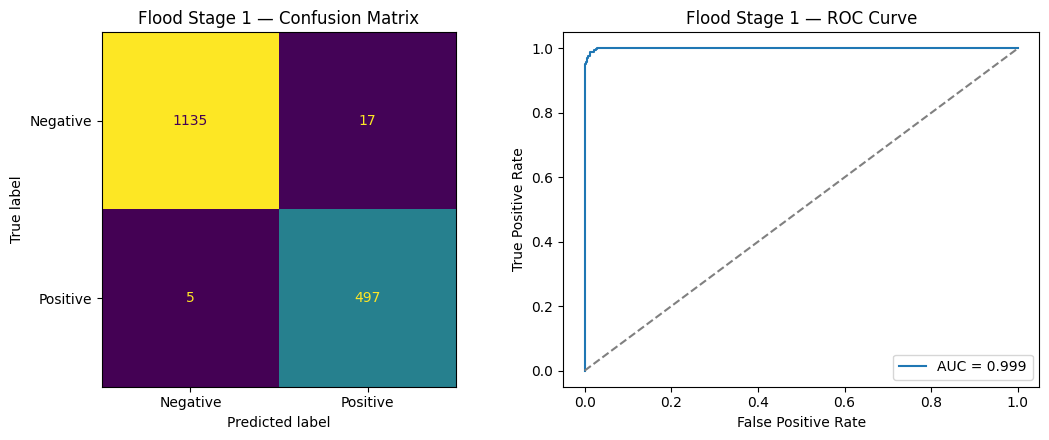

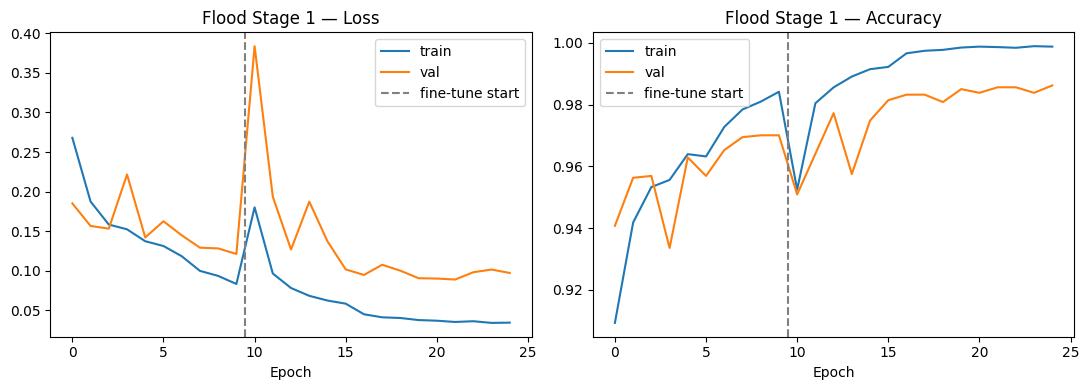

In [14]:
flood_model, flood_h1, flood_h1_ft, flood_results = train_binary_classifier(
    task_name="Flood Stage 1",
    positive_class="Flood",
    save_path=os.path.join(OUT_DIR, "flood_stage1_classifier.h5"),
)


## Section F — Stage 2: Water Segmentation (U-Net, FloodNet)\n\nOnly *invoked* at inference time when Stage 1 predicts \"flood\" — see the cascade in Section H.

In [15]:
def load_seg_sample(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, SEG_IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, SEG_IMG_SIZE, method="nearest")
    mask = tf.cast(mask, tf.float32)

    binary_mask = tf.cast(tf.equal(mask, float(WATER_CLASS_ID)), tf.float32)
    return img, binary_mask


def augment_seg(image, mask):
    combined = tf.concat([image, mask], axis=-1)  # [H, W, 4]
    combined = tf.image.random_flip_left_right(combined)

    crop_frac = tf.random.uniform([], 0.85, 1.0)
    h = tf.cast(tf.cast(SEG_IMG_SIZE[0], tf.float32) * crop_frac, tf.int32)
    w = tf.cast(tf.cast(SEG_IMG_SIZE[1], tf.float32) * crop_frac, tf.int32)
    combined = tf.image.random_crop(combined, size=[h, w, 4])
    combined = tf.image.resize(combined, SEG_IMG_SIZE, method="nearest")

    image, mask = combined[..., :3], combined[..., 3:]
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.85, upper=1.15)
    image = tf.clip_by_value(image, 0.0, 1.0)
    mask = tf.clip_by_value(tf.round(mask), 0.0, 1.0)
    return image, mask


def make_seg_dataset(pairs, augment=False, shuffle=False):
    img_paths = [p[0] for p in pairs]
    mask_paths = [p[1] for p in pairs]
    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(pairs), seed=SEED)
    ds = ds.map(load_seg_sample, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_seg, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


if USE_OFFICIAL_SPLIT:
    seg_train_pairs = collect_floodnet_pairs(floodnet_official_split["train"])
    seg_val_pairs   = collect_floodnet_pairs(floodnet_official_split["val"])
    seg_test_pairs  = collect_floodnet_pairs(floodnet_official_split["test"])
else:
    seg_train_pairs = floodnet_split_pairs["train"]
    seg_val_pairs   = floodnet_split_pairs["val"]
    seg_test_pairs  = floodnet_split_pairs["test"]

print(f"Segmentation split sizes -> train: {len(seg_train_pairs)}, "
      f"val: {len(seg_val_pairs)}, test: {len(seg_test_pairs)}")

seg_train_ds = make_seg_dataset(seg_train_pairs, augment=True, shuffle=True)
seg_val_ds   = make_seg_dataset(seg_val_pairs, augment=False, shuffle=False)
seg_test_ds  = make_seg_dataset(seg_test_pairs, augment=False, shuffle=False)


Segmentation split sizes -> train: 318, val: 39, test: 41


In [16]:
def build_unet_mobilenetv2(input_shape=(*SEG_IMG_SIZE, 3)):
    inputs = layers.Input(shape=input_shape)
    base = MobileNetV2(weights="imagenet", include_top=False, input_tensor=inputs)
    base.trainable = False

    skip_layer_names = [
        "block_1_expand_relu",   # 1/2
        "block_3_expand_relu",   # 1/4
        "block_6_expand_relu",   # 1/8
        "block_13_expand_relu",  # 1/16
    ]
    base_layer_names = {l.name for l in base.layers}
    missing = [n for n in skip_layer_names if n not in base_layer_names]
    if missing:
        raise ValueError(
            f"Expected MobileNetV2 layer names not found: {missing}. "
            "Run base.summary() to find the correct skip-connection layer names "
            "for this TF/Keras version and update skip_layer_names."
        )

    skips = [base.get_layer(name).output for name in skip_layer_names]
    bottleneck = base.output  # 1/32

    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Conv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        return x

    def upsample_block(x, skip, filters):
        x = layers.Conv2DTranspose(filters, 3, strides=2, padding="same")(x)
        x = layers.Concatenate()([x, skip])
        x = conv_block(x, filters)
        return x

    x = conv_block(bottleneck, 512)
    x = layers.Dropout(0.3)(x)

    x = upsample_block(x, skips[3], 256)   # -> 1/16
    x = upsample_block(x, skips[2], 128)   # -> 1/8
    x = upsample_block(x, skips[1], 64)    # -> 1/4
    x = upsample_block(x, skips[0], 32)    # -> 1/2

    x = layers.Conv2DTranspose(16, 3, strides=2, padding="same")(x)  # -> 1/1
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    return model, base


In [17]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    bce = tf.reduce_mean(bce)
    return bce + dice_loss(y_true, y_pred)


def iou_metric(y_true, y_pred, smooth=1e-6, threshold=0.5):
    y_pred_bin = tf.cast(y_pred >= threshold, tf.float32)
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred_bin, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


/tmp/ipykernel_16/3048911732.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights="imagenet", include_top=False, input_tensor=inputs)


--- Phase 1: training decoder, MobileNetV2 encoder frozen ---
Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 162s 14s/step - dice_coefficient: 0.0042 - iou_metric: 0.0024 - loss: 1.7848 - val_dice_coefficient: 0.0033 - val_iou_metric: 0.0016 - val_loss: 120.1694 - learning_rate: 0.0010
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 137s 13s/step - dice_coefficient: 0.0041 - iou_metric: 0.0023 - loss: 1.4951 - val_dice_coefficient: 0.0033 - val_iou_metric: 0.0016 - val_loss: 5710.2056 - learning_rate: 0.0010
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 140s 13s/step - dice_coefficient: 0.0041 - iou_metric: 0.0040 - loss: 1.3802 - val_dice_coefficient: 0.0033 - val_iou_metric: 0.0016 - val_loss: 2408.3062 - learning_rate: 0.0010
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 164s 16s/step - dice_coefficient: 0.0041 - iou_metric: 0.0028 - loss: 1.3290 - val_dice_coefficient: 0.0036 - val_iou_metric: 0.0017 - val_loss: 313.6263 - learning_rate: 5.0000e-04
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 157s 15s/step - dice_coefficie

Saved segmentation model to /kaggle/working/flood_stage2_segmentation.h5


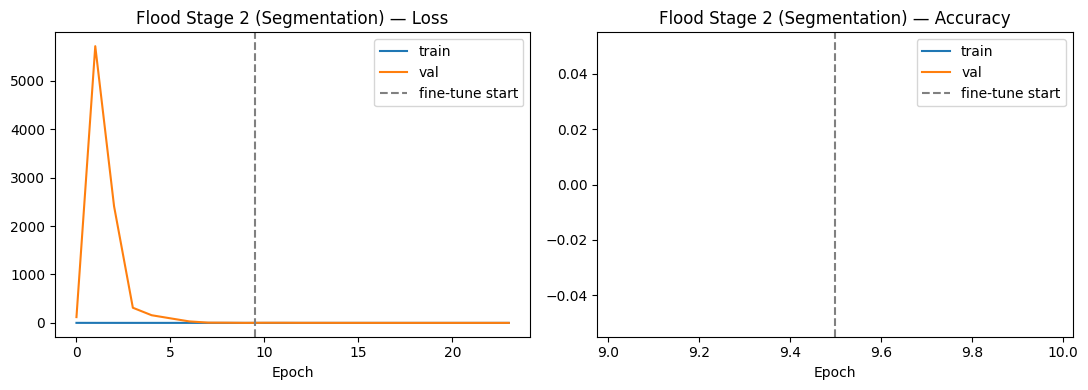

In [18]:
seg_model, seg_base = build_unet_mobilenetv2()

seg_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=bce_dice_loss,
    metrics=[iou_metric, dice_coefficient],
)

print("--- Phase 1: training decoder, MobileNetV2 encoder frozen ---")
seg_callbacks_head = [
    EarlyStopping(monitor="val_iou_metric", mode="max", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
]
seg_hist_head = seg_model.fit(
    seg_train_ds, validation_data=seg_val_ds,
    epochs=SEG_HEAD_EPOCHS, callbacks=seg_callbacks_head, verbose=1,
)

print("\n--- Phase 2: fine-tuning last encoder layers ---")
seg_base.trainable = True
for layer in seg_base.layers[:-SEG_FINETUNE_UNFREEZE_LAST]:
    layer.trainable = False

seg_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[iou_metric, dice_coefficient],
)

seg_callbacks_ft = [
    EarlyStopping(monitor="val_iou_metric", mode="max", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
]
seg_hist_finetune = seg_model.fit(
    seg_train_ds, validation_data=seg_val_ds,
    epochs=SEG_FINETUNE_EPOCHS, callbacks=seg_callbacks_ft, verbose=1,
)

seg_save_path = os.path.join(OUT_DIR, "flood_stage2_segmentation.h5")
seg_model.save(seg_save_path)
print(f"Saved segmentation model to {seg_save_path}")

plot_training_curves(seg_hist_head, seg_hist_finetune, "Flood Stage 2 (Segmentation)")


In [19]:
per_image_ious, per_image_dices = [], []
all_imgs, all_gt_masks, all_pred_masks = [], [], []

for images, masks in seg_test_ds:
    preds = seg_model.predict(images, verbose=0)
    preds_bin = (preds >= 0.5).astype(np.float32)

    for i in range(images.shape[0]):
        gt = masks[i].numpy().ravel()
        pr = preds_bin[i].ravel()
        intersection = np.sum(gt * pr)
        union = np.sum(gt) + np.sum(pr) - intersection
        iou = (intersection + 1e-6) / (union + 1e-6)
        dice = (2 * intersection + 1e-6) / (np.sum(gt) + np.sum(pr) + 1e-6)
        per_image_ious.append(iou)
        per_image_dices.append(dice)
        all_imgs.append(images[i].numpy())
        all_gt_masks.append(masks[i].numpy())
        all_pred_masks.append(preds_bin[i])

per_image_ious = np.array(per_image_ious)
per_image_dices = np.array(per_image_dices)

print(f"Flood Stage 2 — Test set (n={len(per_image_ious)})")
print(f"Mean IoU : {per_image_ious.mean():.4f} (std {per_image_ious.std():.4f})")
print(f"Mean Dice: {per_image_dices.mean():.4f} (std {per_image_dices.std():.4f})")

seg_results = {
    "mean_iou": float(per_image_ious.mean()),
    "std_iou": float(per_image_ious.std()),
    "mean_dice": float(per_image_dices.mean()),
    "std_dice": float(per_image_dices.std()),
}


Flood Stage 2 — Test set (n=41)
Mean IoU : 0.6123 (std 0.4849)
Mean Dice: 0.6144 (std 0.4828)


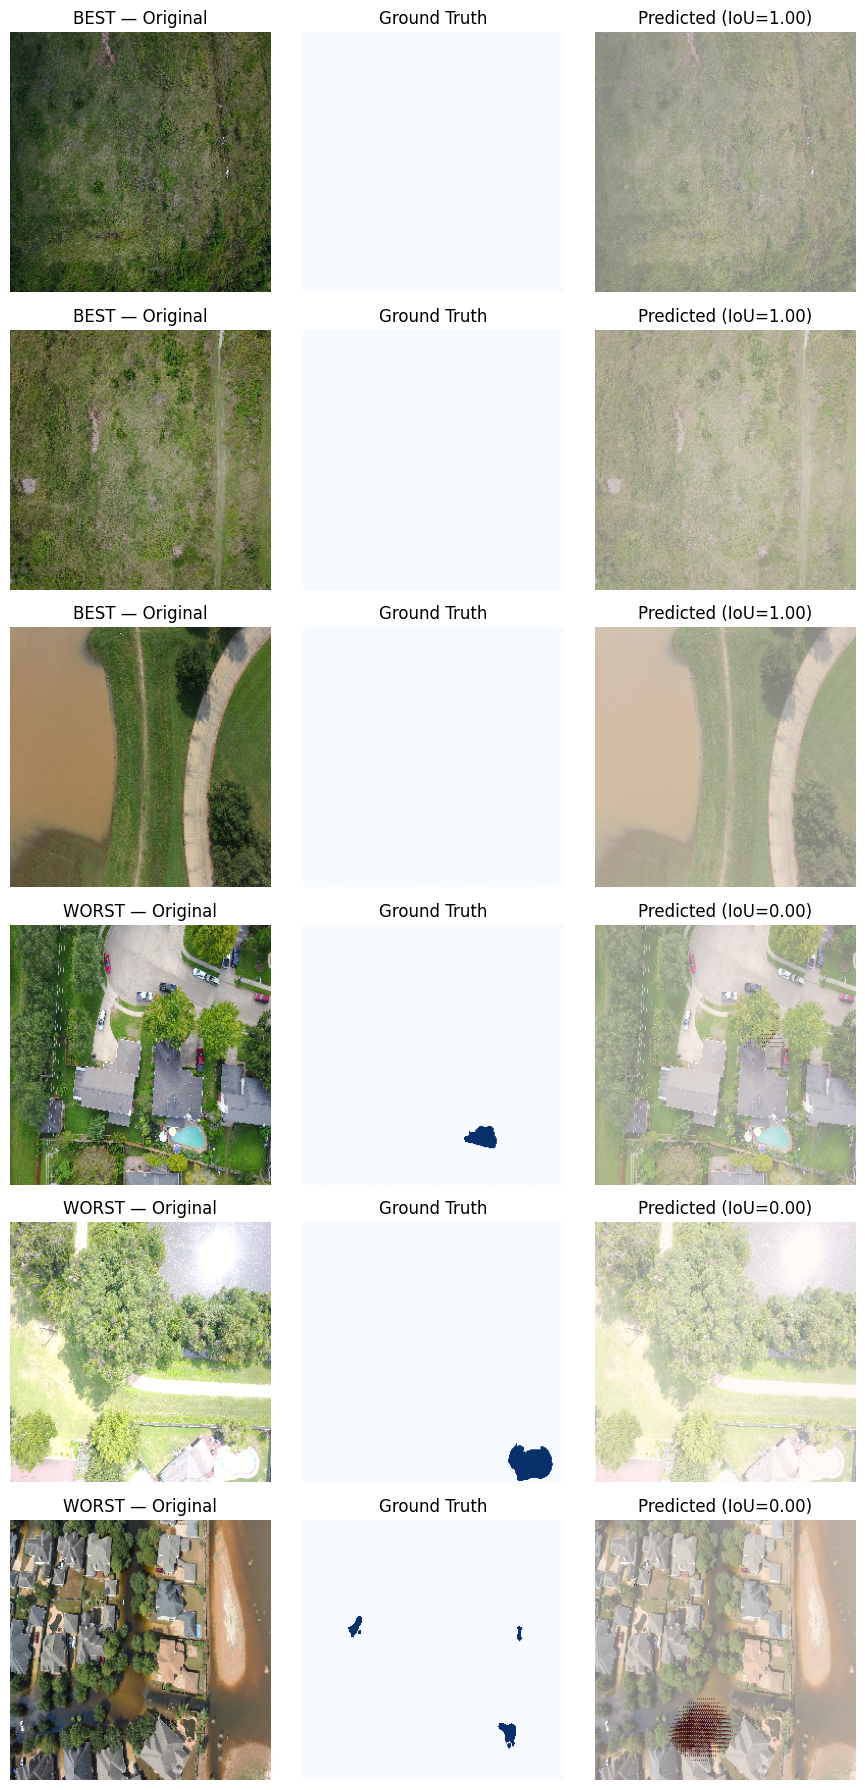

In [20]:
order = np.argsort(-per_image_ious)
best_idx = order[:3]
worst_idx = order[-3:]
show_idx = list(best_idx) + list(worst_idx)

fig, axes = plt.subplots(len(show_idx), 3, figsize=(9, 3 * len(show_idx)))
for row, idx in enumerate(show_idx):
    tag = "BEST" if row < 3 else "WORST"
    axes[row, 0].imshow(all_imgs[idx])
    axes[row, 0].set_title(f"{tag} — Original")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(all_gt_masks[idx].squeeze(), cmap="Blues")
    axes[row, 1].set_title("Ground Truth")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(all_imgs[idx])
    axes[row, 2].imshow(all_pred_masks[idx].squeeze(), cmap="Reds", alpha=0.5)
    axes[row, 2].set_title(f"Predicted (IoU={per_image_ious[idx]:.2f})")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()


## Section G — Results Summary

In [21]:
summary_df = pd.DataFrame([
    {"model": "Flood Stage 1 (classifier)", **flood_results},
    {"model": "Flood Stage 2 (segmentation)",
     "accuracy": np.nan, "precision": np.nan, "recall": np.nan, "f1": np.nan, "roc_auc": np.nan,
     "mean_iou": seg_results["mean_iou"], "mean_dice": seg_results["mean_dice"]},
])
print(summary_df.to_string(index=False))

for path in [
    os.path.join(OUT_DIR, "flood_stage1_classifier.h5"),
    os.path.join(OUT_DIR, "flood_stage2_segmentation.h5"),
]:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"{path}  ({size_mb:.1f} MB)")
    else:
        print(f"MISSING: {path}")


                       model  accuracy  precision  recall       f1  roc_auc  mean_iou  mean_dice
  Flood Stage 1 (classifier)  0.986699   0.966926 0.99004 0.978346 0.999381       NaN        NaN
Flood Stage 2 (segmentation)       NaN        NaN     NaN      NaN      NaN  0.612257   0.614351
/kaggle/working/flood_stage1_classifier.h5  (29.4 MB)
/kaggle/working/flood_stage2_segmentation.h5  (170.5 MB)


## Section H — Cascade Inference\n\nStage 2 segmentation only runs when Stage 1 predicts \"flood\" — this mirrors the on-device inference logic the drone would actually run.

In [22]:
def run_cascade(image_path, stage1_model, stage2_model, threshold=0.5):
    raw = tf.io.read_file(image_path)
    raw = tf.image.decode_jpeg(raw, channels=3)

    img_224 = tf.image.resize(raw, CLF_IMG_SIZE)
    img_224 = tf.cast(img_224, tf.float32) / 255.0
    prob = float(stage1_model.predict(img_224[None, ...], verbose=0)[0, 0])
    label = "FLOOD" if prob >= threshold else "NOT FLOOD"

    water_mask = None
    if label == "FLOOD":
        img_256 = tf.image.resize(raw, SEG_IMG_SIZE)
        img_256 = tf.cast(img_256, tf.float32) / 255.0
        pred = stage2_model.predict(img_256[None, ...], verbose=0)[0]
        water_mask = (pred >= 0.5).astype(np.float32).squeeze()

    return {
        "image_path": image_path,
        "original_img": raw.numpy(),
        "confidence": prob,
        "label": label,
        "triggered": label == "FLOOD",
        "water_mask": water_mask,
    }


def visualise_cascade(result):
    if not result["triggered"]:
        fig, ax = plt.subplots(1, 1, figsize=(4, 4))
        ax.imshow(result["original_img"])
        ax.set_title(f"{result['label']} (conf={result['confidence']:.2f})\nStage 2 skipped")
        ax.axis("off")
    else:
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(result["original_img"])
        axes[0].set_title(f"{result['label']} (conf={result['confidence']:.2f})")
        axes[0].axis("off")

        img_resized = tf.image.resize(result["original_img"], SEG_IMG_SIZE).numpy() / 255.0
        axes[1].imshow(img_resized)
        axes[1].imshow(result["water_mask"], cmap="Blues", alpha=0.5)
        axes[1].set_title("Stage 2 — water mask overlay")
        axes[1].axis("off")
    plt.tight_layout()
    plt.show()


image_281.png -> FLOOD (conf=0.999), Stage 2 triggered: True


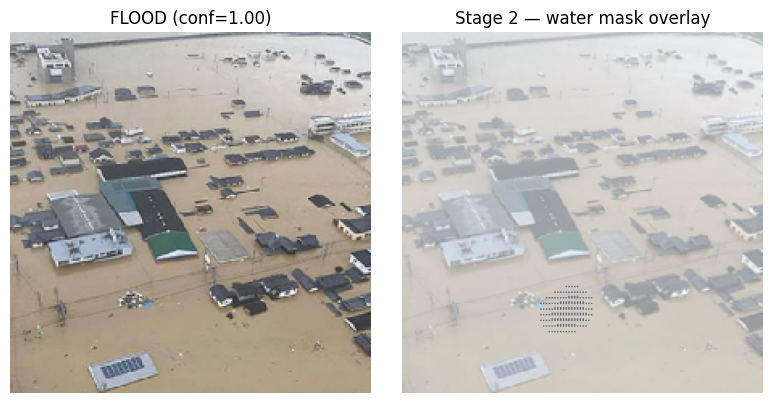

image_418.png -> FLOOD (conf=1.000), Stage 2 triggered: True


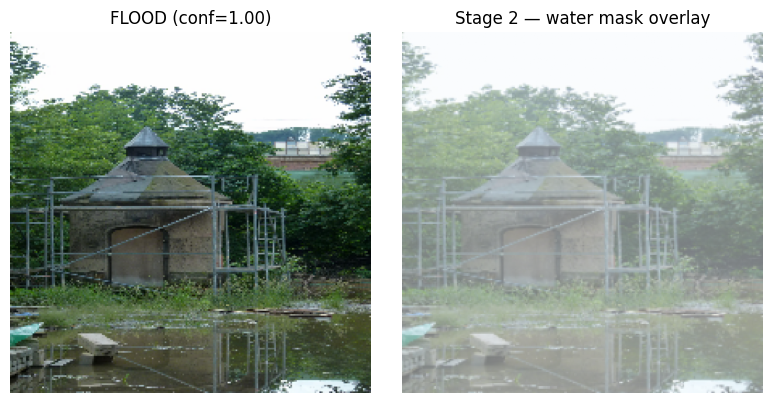

image_328.png -> FLOOD (conf=1.000), Stage 2 triggered: True


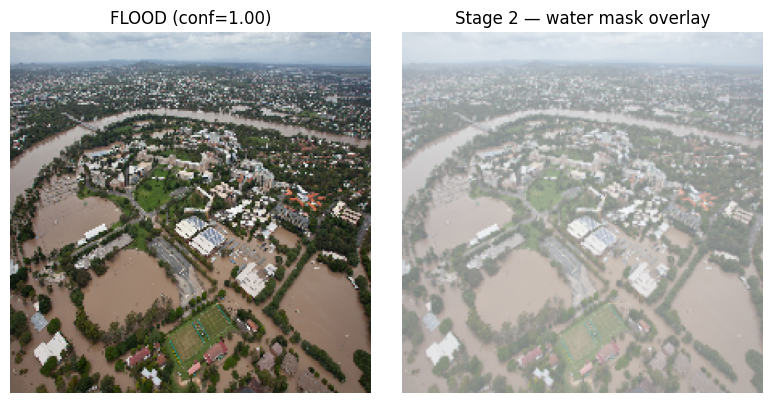

image_350.png -> FLOOD (conf=1.000), Stage 2 triggered: True


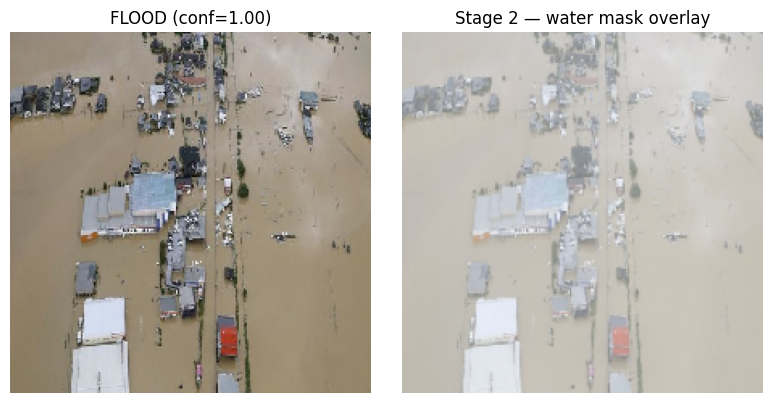

image_1171.png -> NOT FLOOD (conf=0.000), Stage 2 triggered: False


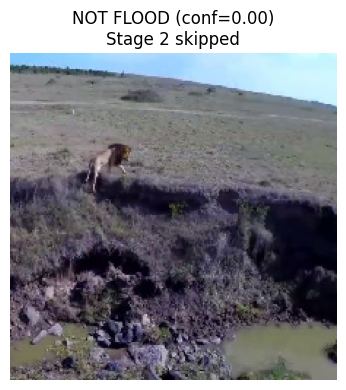

image_806.png -> NOT FLOOD (conf=0.000), Stage 2 triggered: False


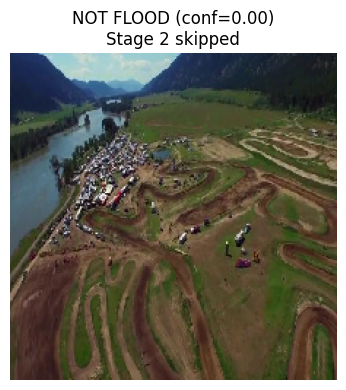

In [23]:
flood_test_dir = resolve_class_dir(aider_splits["test"], "Flood")
normal_test_dir = resolve_class_dir(aider_splits["test"], "Normal")

flood_demo_imgs = [os.path.join(flood_test_dir, f)
                    for f in os.listdir(flood_test_dir)[:4]]
non_flood_demo_imgs = [os.path.join(normal_test_dir, f)
                        for f in os.listdir(normal_test_dir)[:2]]

demo_imgs = flood_demo_imgs + non_flood_demo_imgs

for img_path in demo_imgs:
    result = run_cascade(img_path, flood_model, seg_model)
    print(f"{os.path.basename(img_path)} -> {result['label']} (conf={result['confidence']:.3f}), "
          f"Stage 2 triggered: {result['triggered']}")
    visualise_cascade(result)
